# Bjerknes feedback changes over time

## imports

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import seaborn as sns
import xarray as xr
import tqdm
import pathlib
import cmocean
import os
import copy
import time

# Import custom modules
import src.utils

## set plotting specs
sns.set(rc={"axes.facecolor": "white", "axes.grid": False})

## bump up DPI
mpl.rcParams["figure.dpi"] = 100

## get filepaths
DATA_FP = pathlib.Path(os.environ["DATA_FP"])
SAVE_FP = pathlib.Path(os.environ["SAVE_FP"])

## Specify kwargs

In [2]:
## MONTH FOR PLOTTING
SEL_MONTH = lambda x : x.sel(month=slice(10,12)).mean("month")
MONTH0 = 10

## WHETHER TO COMPUTE BY MEMBER
BY_MEMBER = True

if BY_MEMBER:
    DIMS = ["time"]
else:
    DIMS = ["time", "member"]

## Load pre-computed regression coefficients

In [3]:
## SPECIFY t_variable
T_VAR = "T_34"

## path where data is located
save_fp = pathlib.Path(SAVE_FP, "bjerknes_v4", f"coefs_xvars={T_VAR}-h_w")
load = lambda n : xr.open_dataset(save_fp / f"{n}.nc")
coefs = {n:load(n) for n in ["all","pos","neg"]}

## path where data is located
save_fp = pathlib.Path(SAVE_FP, "bjerknes_v4", F"coefs_xvars={T_VAR}")
load = lambda n : xr.open_dataset(save_fp / f"{n}.nc").squeeze(drop=True)
coefs_T = {n:load(n) for n in ["all","pos","neg"]}

## Funcs

### Misc

In [4]:
def window(x):
    return src.utils.get_windowed(x, stride=120)


def load_consolidated_wide():
    """utility function to load consolidated data"""

    ## directory with data
    CONS_DIR = pathlib.Path(os.environ["DATA_FP"], "cesm", "consolidated_05")

    ## function to align and open
    kwargs = dict(pop_vars=["u", "u_comp", "T", "T_comp", "w", "w_comp"])
    align_and_open = lambda fp: src.utils.align_pop_times(xr.open_dataset(fp), **kwargs)

    ## open data and align pop times
    kwargs = dict(pop_vars=["u", "u_comp", "T", "T_comp", "w", "w_comp"])
    forced = align_and_open(CONS_DIR / "forced.nc")
    anom = align_and_open(CONS_DIR / "anom.nc")

    return forced, anom


def regress_over_time(data, x_vars, y_vars, dims=["time", "member"]):
    """regression over time"""

    ## get windowed data
    data_ = window(data)

    ## empty list to hold coefficients
    coefs = []

    ## shared args
    kwargs = dict(x_vars=x_vars, y_vars=y_vars, dims=dims)

    ## loop thru years
    for year in tqdm.tqdm(data_.year):

        ## get grouped data
        data_y = data_.sel(year=year).groupby("time.month")

        ## do regression
        coefs.append(data_y.map(src.utils.regress_xr_proj, **kwargs))

    return xr.concat(coefs, dim=data_.year)


def regress_wrapper(data, x_vars, y_var, y_fn, dims=["time", "member"]):
    """regression over time"""

    ## prep data
    y_data = src.utils.reconstruct_wrapper(data[[f"{y_var}", f"{y_var}_comp"]], fn=y_fn)

    ## subset for data
    data_ = xr.merge([data[x_vars], y_data])

    return regress_over_time(data_, x_vars=x_vars, y_vars=[y_var], dims=dims)


def frac_change(x):
    """fractional change"""
    return x / x.isel(year=0) - 1

def check_dims(x):
    """make sure dimensions are ok before averaging"""
    ## check if latitude is in ssh
    if "latitude" in x.dims:
        x_ = copy.deepcopy(x)
    else:
        x_ = x.expand_dims("latitude")

    ## check if z_t is in ssh
    if "z_t" in x.dims:
        x_ = copy.deepcopy(x_)
    else:
        x_ = x_.expand_dims("z_t")

    return x_

def get_ddt(data):
    """differentiate with respect to time"""
    data_ = copy.deepcopy(data)
    data_ = data_.assign_coords({"t_idx": ("time", np.arange(len(data_.time)))})
    data_ = data_.swap_dims({"time": "t_idx"})
    return data_.differentiate("t_idx").swap_dims({"t_idx": "time"})

### Plotting

In [5]:
def make_scatter_ax(ax, anom_, xvar, yvar, month, label, by_season=True):
    """scatter plot of data for given month"""

    ## prep func
    if by_season:
        get_season = lambda x: src.utils.sel_month(
            x.resample({"time": "QS-JAN"}).mean(), month
        )

    else:
        get_season = lambda x: src.utils.sel_month(x, month)

    prep = lambda x: get_season(x).transpose("time", "member")

    ## get plot data
    plot_data = (prep(anom_[xvar]), prep(anom_[yvar]))

    ## get stats
    corr = xr.corr(*plot_data)
    cov = xr.cov(*plot_data)
    m = cov / plot_data[0].var()

    ## plot data
    ax.scatter(*plot_data, s=3, label=f"m = {m.item():.1e}\nr = {corr.item():.2f}")
    ax.set_title(f"{label}")

    ## formatting
    ax_kwargs = dict(ls="--", c="gray", lw=0.5)
    ax.axvline(0, **ax_kwargs)
    ax.axhline(0, **ax_kwargs)
    ax.legend(prop=dict(size=10))

    return ax


def make_scatter(anom_, xvar, yvar, month, by_season=True):
    """scatter plot of data for given month"""

    fig, axs = plt.subplots(1, 4, figsize=(11, 2.5), layout="constrained")

    for ax, t_idx, label in zip(
        axs,
        [["1850", "1879"], ["1995", "2024"], ["2035", "2064"], ["2071", "2100"]],
        ["1865", "2010", "2050", "2085"],
    ):

        ## helper func
        prep = lambda x: x.sel(time=slice(*t_idx))

        ## scatter plot of data
        ax = make_scatter_ax(
            ax,
            prep(anom_),
            xvar=xvar,
            yvar=yvar,
            month=month,
            by_season=by_season,
            label=label,
        )

    ## format/scale axes
    src.utils.set_lims(axs)
    for ax in axs[1:]:
        ax.set_yticks([])

    return fig, axs

def plot_timeseries(coefs, sel_fn=lambda x : x):
    """plot timeseries comparison"""

    fig, axs = plt.subplots(1, 3, figsize=(8, 2.5))

    ## loop thru pos and negative
    for i, (name, color) in enumerate(zip(["pos", "neg"], ["r", "b"])):

        ## plot median and bounds
        for q, lw in zip([0.5, 0.1, 0.9], [2, 0.6, 0.6]):

            ## plot neutral and pos/or neg
            for name_, color_ in zip(["all", name], ["k", color]):

                ## finally, plot data
                axs[i].plot(
                    coefs.year,
                    sel_fn(coefs)[name_].quantile(q=q, dim="member"),
                    c=color_,
                    lw=lw,
                )

            ## plot on shared axs
            axs[2].plot(
                coefs.year,
                sel_fn(coefs)[name].quantile(q=q, dim="member"),
                c=color,
                lw=lw,
            )

    ## formatting
    for ax in axs:
        ax.set_xticks([1870, 2010, 2080])
        ax_kwargs = dict(ls="--", c="gray", lw=0.8)
        ax.axvline(2010, **ax_kwargs)
        ax.axhline(0, **ax_kwargs)
    src.utils.set_lims(axs)

    for ax in axs[1:]:
        ax.set_yticks([])

    return fig, axs


def plot_zonal_structure(coefs, sel_fn=lambda x : x):
    """plot zonal structure of coefficients over time"""

    fig, axs = plt.subplots(1, 4, figsize=(10, 2.5), layout="constrained")

    for ax, y in zip(axs, [1865, 2010, 2050, 2085]):

        ## get data for year
        ax.set_title(y)
        coefs_y = sel_fn(coefs).sel(year=y, method="nearest")

        ## select data
        for n, color in zip(["all", "pos", "neg"], ["k", "r", "b"]):

            ax.plot(coefs.longitude, coefs_y[n].mean("member"), c=color)

    src.utils.set_lims(axs)
    for ax in axs[1:]:
        ax.set_yticks([])

    for ax in axs:
        ax.set_xticks([140, 190, 240, 280])
        ax_kwargs = dict(ls="--", c="gray", lw=0.8)
        ax.axhline(0, **ax_kwargs)

    return fig, axs


def add_vticks(axs, xticks, xlines=None):
    """add vertical lines to axs"""

    ## specify line style
    ax_kwargs = dict(ls="--", c="gray", lw=0.8)

    ## loop thru axs
    for ax in axs:
        ax.set_xticks(xticks)
        if xlines is not None:
            for x0 in xlines:
                ax.axvline(x0, **ax_kwargs)

    return

def plot_vertical_structure(coefs, sel_fn):
    """plot vertical structure of coefficients over time"""

    fig, axs = plt.subplots(1, 4, figsize=(10, 2.5), layout="constrained")

    for ax, y in zip(axs, [1865, 2010, 2050, 2085]):

        ## get data for year
        ax.set_title(y)
        coefs_y = sel_fn(coefs).sel(year=y, method="nearest")

        ## select data
        for n, color in zip(["all", "pos", "neg"], ["k", "r", "b"]):

            ax.plot(coefs_y[n].mean("member"), coefs.z_t, c=color)

    for ax in axs:
        ax.set_ylim([150,5])

        ax_kwargs = dict(ls="--", c="gray", lw=0.8)
        ax.axhline(50, **ax_kwargs)
        ax.axhline(80, **ax_kwargs)
        ax.axvline(0, **ax_kwargs)

    src.utils.set_lims(axs)
    axs[0].set_yticks([0,50,80])
    for ax in axs[1:]:
        ax.set_yticks([])
    return fig, axs

## Load data

#### $T$, $h$

In [6]:
## open data
Th = src.utils.load_cesm_indices(load_z20=True)

### Spatial data

#### most data

In [7]:
## load spatial data
forced, anom = src.utils.load_consolidated()

## add T,h information
anom = xr.merge([anom, Th])

#### "wide" subsurface data

In [8]:
## should we use "wide" data?
USE_WIDE = True

## load spatial data
forced_wide, anom_wide = load_consolidated_wide()

if USE_WIDE:

    for v in list(forced_wide):
        forced[v] = forced_wide[v]
        anom[v] = anom_wide[v]

#### max grad thermocline

In [9]:
h_mg_forced, h_mg = src.utils.load_h_data(max_grad=True)

### scaling for mean thermocline depth

#### Mean thermocline depth

In [10]:
hbar_scale = xr.open_dataarray(
    pathlib.Path(SAVE_FP, "cesm_Hbar_scale_v2.nc"),
)

### Compute OHC

In [11]:
## should we use mixed layer T?
# use_T_ml = True
use_T_ml = False

## specify subsetting funcs
LATS = dict(latitude=slice(-5, 5))
LATS_H = dict(latitude=slice(-5, 5))
LONS_E = dict(longitude=slice(210, 270))
# LONS_W = dict(longitude=slice(120, 160))
LONS_W = dict(longitude=slice(120, 180))
LONS_TAU = dict(longitude=slice(150, 230))

Set funcs

In [12]:
## helper func to select and avg
def sel_helper(x, lats, lons):
    """helper func to avg over lats/lons"""

    ## first, average over lons
    x_avg = x.sel(lons).mean("longitude")

    if "latitude" in x_avg.dims:
        x_avg = x_avg.sel(lats).mean("latitude")

    return x_avg


## specify functions
TAU_FN = lambda x: sel_helper(x, LATS, LONS_TAU)
TAU_FN_3 = lambda x: sel_helper(x, LATS, LONS_E)
He_FN = lambda x: sel_helper(x, LATS_H, LONS_E)
Hw_FN = lambda x: sel_helper(x, LATS_H, LONS_W)
Hgrad_FN = lambda x: He_FN(x) - Hw_FN(x)


## specify entrainment / ML averages
LON_AVG = lambda x: x.sel(longitude=slice(210, 270)).mean("longitude")
LON_AVG_34 = lambda x: x.sel(longitude=slice(190, 240)).mean("longitude")
ENT_AVG = lambda x: x.sel(z_t=slice(50, 80)).mean("z_t")
ML_AVG = lambda x: x.sel(z_t=slice(None, 50)).mean("z_t")

## get T3 volume avg
T3_ENT_AVG = lambda x: ENT_AVG(LON_AVG(x))
T3_ML_AVG = lambda x: ML_AVG(LON_AVG(x))
T34_ML_AVG = lambda x: ML_AVG(LON_AVG_34(x))

if use_T_ml:
    anom["T_3"] = src.utils.reconstruct_wrapper(
        anom[["T", "T_comp"]],
        fn=T3_ML_AVG,
    )["T"]

In [13]:
## should we use OHC?
USE_OHC = True

lon_avg = lambda x, lons: x.sel(lons).mean("longitude")
lat_avg = lambda x: x.sel(latitude=slice(-5, 5)).mean("latitude")

if USE_OHC:

    ## compute ohc
    anom["h_w"] = src.utils.reconstruct_wrapper(
        anom_wide[["T", "T_comp"]],
        lambda x: lon_avg(x.integrate("z_t"), LONS_W) / 300,
    )["T"]
    anom["h_e"] = src.utils.reconstruct_wrapper(
        anom_wide[["T", "T_comp"]],
        lambda x: lon_avg(x.integrate("z_t"), LONS_E) / 300,
    )["T"]

else:
    anom["h_w"] = src.utils.reconstruct_wrapper(
        anom[["ssh", "ssh_comp"]],
        lambda x: lat_avg(lon_avg(x, LONS_W)),
    )["ssh"]
    anom["h_e"] = src.utils.reconstruct_wrapper(
        anom[["ssh", "ssh_comp"]],
        lambda x: lat_avg(lon_avg(x, LONS_E)),
    )["ssh"]

### T vs. ddt(SST)$

#### Load coefficients

In [14]:
## specify which longitudes to reduce over
# ddt_LON_RANGE = [190,240]
ddt_LON_RANGE = [210,270]

## specify which variable to use ("T" or "sst")
YVAR = "sst"

## function to select data
sel_var = lambda x : x[f"ddt_{YVAR}"].sel(j=T_VAR)

## load coefs
R_proj = 12 * xr.merge(sel_var(c).rename(n) for n,c in coefs.items())

#### Plot spatial structure

reconstruct spatial strucure

In [15]:
def reduce_yz(x):

    if "z_t" not in x.dims:
        x = x.expand_dims("z_t")

    if "latitude" not in x.dims:
        x = x.expand_dims("latitude")

    idx = dict(z_t=slice(None,50), latitude=slice(-5,5))
    
    return x.sel(idx).mean(["z_t","latitude"])

def reduce_x(x):
    
    ## get averaging dims
    idx = dict(longitude=slice(*ddt_LON_RANGE))
    
    return x.sel(idx).mean("longitude")

def recon_struct(coefs, v="T"):
    """reconstruct spatial structure of coefficients"""

    coefs_struct = src.utils.reconstruct_wrapper(
        xr.merge([coefs.rename(v), anom[f"{v}_comp"]]),
        fn=reduce_yz,
    )

    return coefs_struct[v]

def recon_idx(coefs, v="T"):
    """reconstruct spatial structure of coefficients"""

    coefs_struct = src.utils.reconstruct_wrapper(
        xr.merge([coefs.rename(v), anom[f"{v}_comp"]]),
        fn=lambda y : reduce_x(reduce_yz(y)),
    )

    return coefs_struct[v]

In [16]:
## load coefs
R_struct = xr.merge(
    [recon_struct(R_proj[v], YVAR).rename(v) for v in ["all","pos","neg"]]
)

Plot

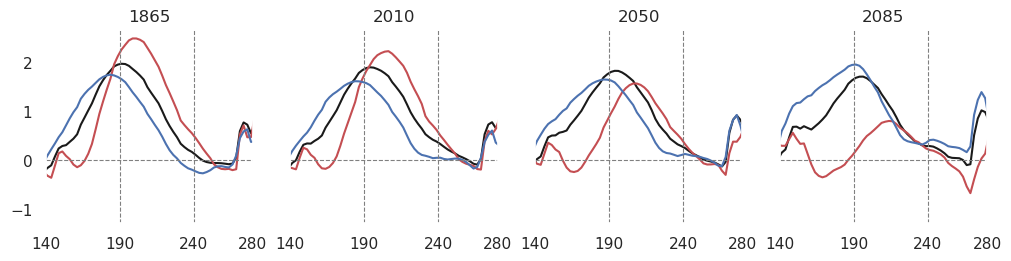

In [17]:
fig,axs = plot_zonal_structure(R_struct, sel_fn=SEL_MONTH)
for ax in axs:
    ax.set_xlim([140,280])

add_vticks(axs, xticks=[140,190,240,280], xlines=[190,240])
plt.show()

#### Timeseries

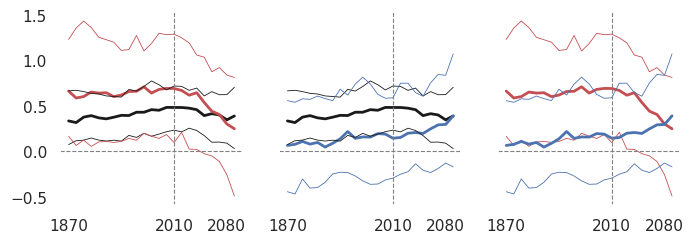

In [18]:
## get index
R = reduce_x(R_struct)

fig, axs = plot_timeseries(coefs=R, sel_fn=SEL_MONTH)
plt.show()

#### Scatter plot

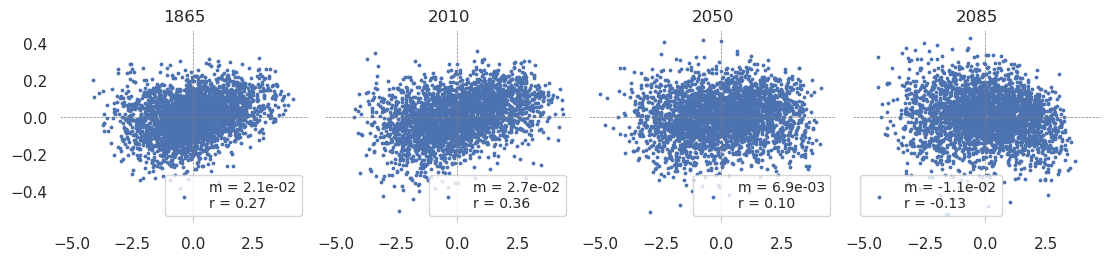

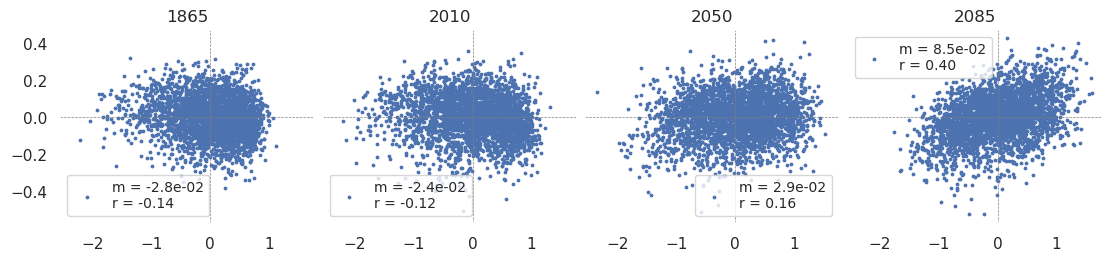

In [19]:
scatter_data = xr.merge(
    [
        get_ddt(recon_idx(anom[YVAR], YVAR)).rename(f"ddt_{YVAR}"),
        anom[["T_3", "T_34", "h_w"]],
    ]
)

for xvar in [T_VAR,"h_w"]:
    fig,axs = make_scatter(scatter_data, xvar=xvar, yvar=f"ddt_{YVAR}", month=MONTH0)
    plt.show()

### T vs. Tsub

#### Load coefficients

In [20]:
## load coefs
gamma_proj = xr.merge(c["T"].rename(n) for n,c in coefs.items())

#### Plot structure

In [21]:
def reduce_x(x):
    """Get Tsub, but don't average over depth yet"""

    # return x.sel(longitude=slice(190,240)).mean("longitude")
    return x.sel(longitude=slice(210,270)).mean("longitude")

def reduce_z(x):
    """Get diff b/n Tsub and Tsurf, but don't average over longitude yet"""

    Tsurf = x.sel(z_t=slice(None,50)).mean("z_t")
    Tsub = x.sel(z_t=slice(51,80)).mean("z_t")

    return Tsub-Tsurf

def recon_struct(coefs):
    """post-process regression coefficients"""

    ## reconstruct mean over equatorial region
    coefs_ = src.utils.reconstruct_wrapper(
        xr.merge([coefs.rename("T"), anom["T_comp"]]),
        fn=reduce_z,
    )
    ## drop extra variables
    mu = coefs_["T"].squeeze(drop=True)

    return mu

def recon_idx(coefs):
    """reconstruct spatial structure of coefficients"""

    coefs_struct = src.utils.reconstruct_wrapper(
        xr.merge([coefs["T"], anom[f"T_comp"]]),
        fn=lambda y : reduce_x(reduce_z(y)),
    )

    return coefs_struct["T"]

In [22]:
## load coefs
gamma_struct = xr.merge(
    [recon_struct(gamma_proj[v]).rename(v) for v in ["all","pos","neg"]]
)

T_34


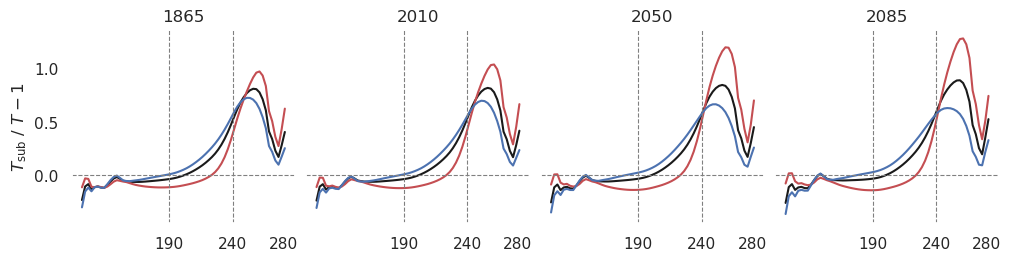

h_w


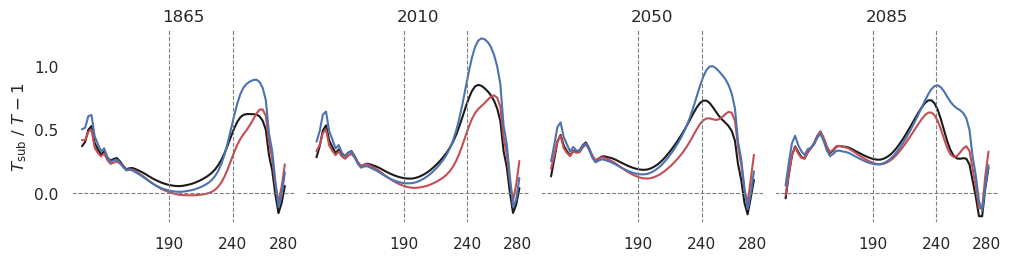

In [23]:
for v in [T_VAR,"h_w"]:
    print(v)

    
    fig, axs = plot_zonal_structure(coefs=gamma_struct.sel(j=v), sel_fn=SEL_MONTH)
    add_vticks(axs, xticks=[190,240,280], xlines=[190,240])
    axs[0].set_ylabel(r"$T_{\text{sub}}~/~T-1$")

    plt.show()

#### Plot timeseries

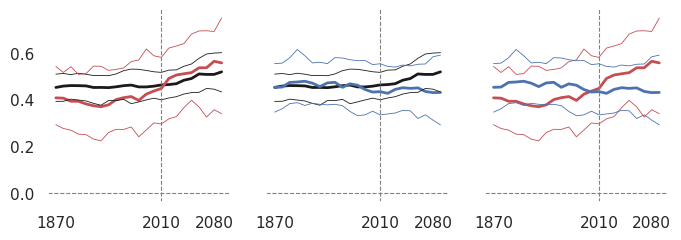

In [24]:
## compute gamma
gamma = reduce_x(gamma_struct)

fig, axs = plot_timeseries(coefs=gamma.sel(j=T_VAR), sel_fn=SEL_MONTH)
plt.show()

#### Scatter

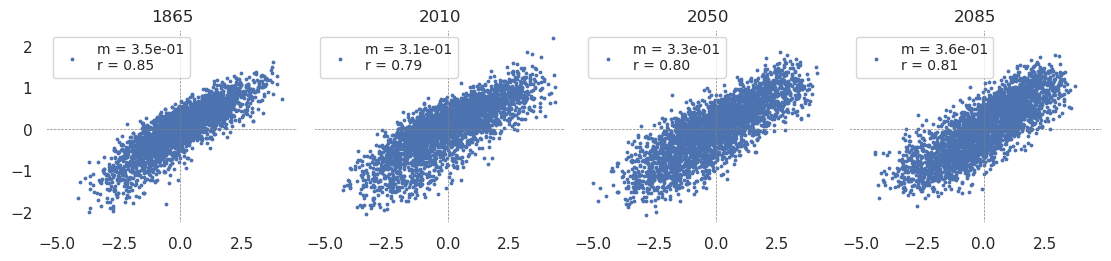

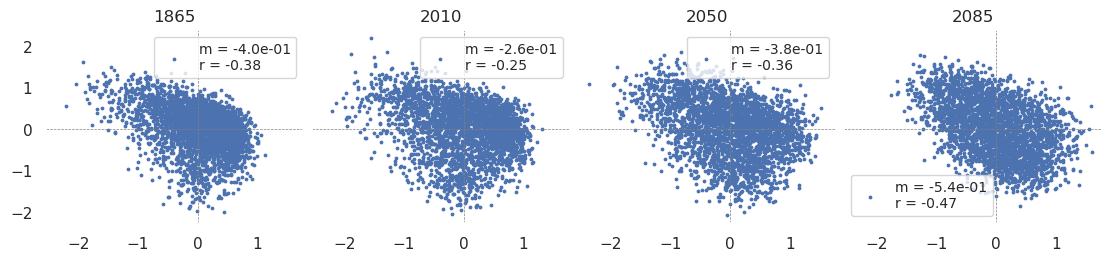

In [25]:
scatter_data = xr.merge(
    [
        recon_idx(anom[["T"]]),
        anom[["T_3", "T_34", "h_w"]],
    ]
)

for xvar in [T_VAR,"h_w"]:
    fig,axs = make_scatter(scatter_data, xvar=xvar, yvar=f"T", month=MONTH0)
    plt.show()

### Damping

#### Load data

In [26]:
## get scaling factor to convert to damping rate (units of K/mo)
sec_per_mo = 8.64e4 * 30
rho = 1.02e3
Cp = 4.2e3
H0 = 50
scale_fac = sec_per_mo / (rho * Cp * H0)

## helper func to get data
prep = lambda x : -12 * x["nhf"] * scale_fac

## load coefs
alpha_proj = xr.merge(prep(c).rename(n) for n,c in coefs_T.items())

#### structure

In [27]:
def reduce_x(x):
    """Get Tsub, but don't average over depth yet"""

    return x.sel(longitude=slice(190,240)).mean("longitude")

def reduce_y(x):
    """Get diff b/n Tsub and Tsurf, but don't average over longitude yet"""

    return x.sel(latitude=slice(-5,5)).mean("latitude")

def recon_struct(coefs):
    """post-process regression coefficients"""

    ## reconstruct mean over equatorial region
    coefs_ = src.utils.reconstruct_wrapper(
        xr.merge([coefs.rename("nhf"), anom["nhf_comp"]]),
        fn=reduce_y,
    )
    ## drop extra variables
    coefs_ = coefs_["nhf"].squeeze(drop=True)

    return coefs_

def recon_idx(coefs):
    """reconstruct spatial structure of coefficients"""

    coefs_struct = src.utils.reconstruct_wrapper(
        xr.merge([coefs["nhf"], anom[f"nhf_comp"]]),
        fn=lambda z : reduce_x(reduce_y(z)),
    )

    return coefs_struct["nhf"]

In [28]:
## load coefs
alpha_struct = xr.merge(
    [recon_struct(alpha_proj[v]).rename(v) for v in ["all","pos","neg"]]
)

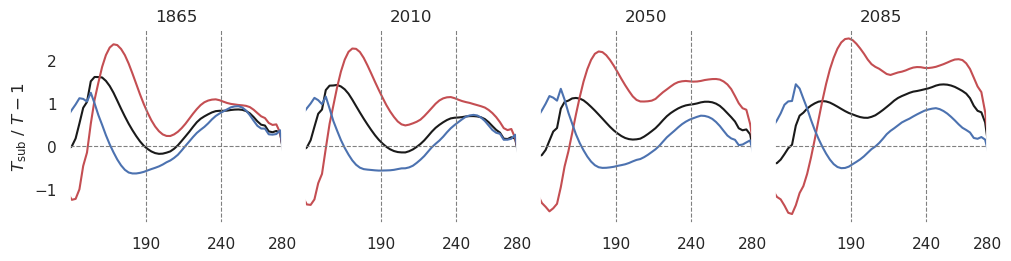

In [29]:
fig, axs = plot_zonal_structure(coefs=alpha_struct, sel_fn=SEL_MONTH)
add_vticks(axs, xticks=[190,240,280], xlines=[190,240])
axs[0].set_ylabel(r"$T_{\text{sub}}~/~T-1$")
for ax in axs:
    ax.set_xlim([140,280])
plt.show()

#### Timeseries

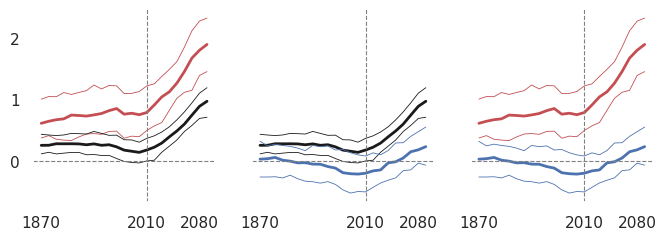

In [30]:
alpha = reduce_x(alpha_struct)

fig, axs = plot_timeseries(coefs=alpha, sel_fn=SEL_MONTH)
plt.show()

#### Scatter

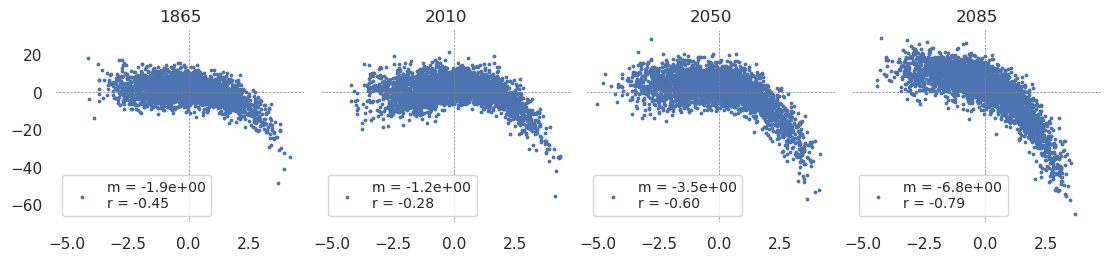

In [31]:
scatter_data = xr.merge(
    [
        recon_idx(anom[["nhf"]]),
        anom[["T_3", "T_34"]],
    ]
)
fig,axs = make_scatter(scatter_data, xvar=T_VAR, yvar="nhf", month=MONTH0)
plt.show()

### wind stress

#### Load data

In [32]:
## load coefs
mu_proj = xr.merge(c["taux"].rename(n) for n,c in coefs_T.items())

#### structure

In [33]:
def reduce_x(x):
    """Get Tsub, but don't average over depth yet"""

    return x.sel(longitude=slice(150,230)).mean("longitude")

def reduce_y(x):
    """Get diff b/n Tsub and Tsurf, but don't average over longitude yet"""

    return x.sel(latitude=slice(-5,5), longitude=slice(140,280)).mean("latitude")

def recon_struct(coefs):
    """post-process regression coefficients"""

    ## reconstruct mean over equatorial region
    coefs_ = src.utils.reconstruct_wrapper(
        xr.merge([coefs.rename("taux"), anom["taux_comp"]]),
        fn=reduce_y,
    )
    ## drop extra variables
    coefs_ = coefs_["taux"].squeeze(drop=True)

    return coefs_

def recon_taux_idx(coefs):
    """reconstruct spatial structure of coefficients"""

    coefs_struct = src.utils.reconstruct_wrapper(
        xr.merge([coefs["taux"], anom["taux_comp"]]),
        fn=lambda z : reduce_x(reduce_y(z)),
    )

    return coefs_struct["taux"]

In [34]:
## load coefs
mu_struct = xr.merge(
    [recon_struct(mu_proj[v]).rename(v) for v in ["all","pos","neg"]]
)

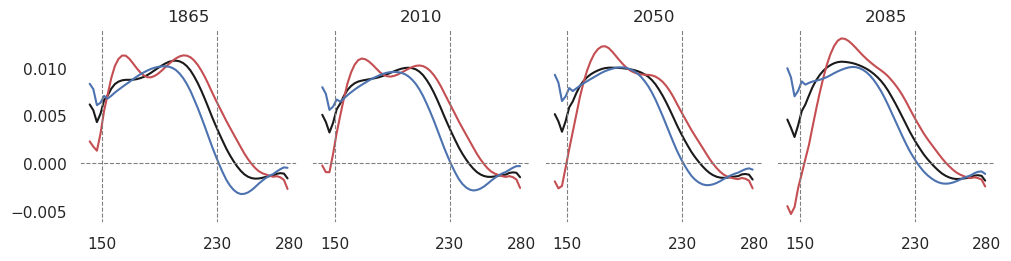

In [35]:
fig, axs = plot_zonal_structure(coefs=mu_struct, sel_fn=SEL_MONTH)

add_vticks(axs, xticks=[150, 230, 280], xlines=[150, 230])

plt.show()

#### Timeseries

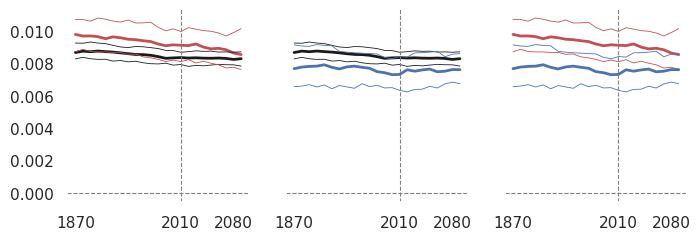

In [36]:
## compute index
mu = reduce_x(mu_struct)

fig, axs = plot_timeseries(coefs=mu, sel_fn=SEL_MONTH)
plt.show()

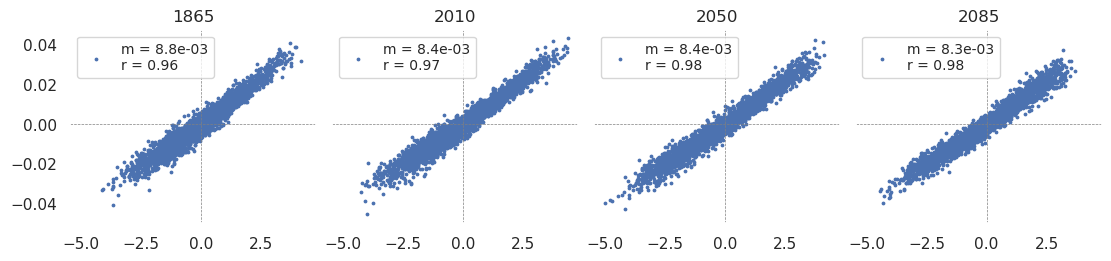

In [37]:
scatter_data = xr.merge(
    [
        recon_taux_idx(anom[["taux"]]),
        anom[["T_3", "T_34"]],
    ]
)
fig,axs = make_scatter(scatter_data, xvar=T_VAR, yvar="taux", month=MONTH0)
plt.show()

#### Add index to ```anom```

In [38]:
anom["taux_idx"] = recon_taux_idx(anom[["taux"]])

### Sverdrup balance

#### Compute

In [39]:
def reduce_y(x):
    """reduce over lat/lon/depth"""

    ## make sure dims are all there
    x_ = check_dims(x)

    ## specify indices
    idx = dict(longitude=slice(120, 280), latitude=slice(-5, 5))

    ## average over lats
    x_ = x_.sel(idx).mean("latitude")

    ## integrate (optionally)
    if len(x_.z_t)>1:
        x_ = x_.integrate("z_t")/300
    else:
        x_ = x_.squeeze(drop=True)
    
    return x_

def postprocess_(coefs, T_var):
    """post-process regression coefficients"""

    ## get recon components
    comps = check_dims(anom[f"{T_var}_comp"])

    ## reconstruct mean over equatorial region
    coefs_ = src.utils.reconstruct_wrapper(
        xr.merge([coefs, comps]),
        fn=reduce_y,
    )

    ## drop extra variables
    coefs_ = coefs_[T_var].squeeze(drop=True)

    return coefs_

In [40]:
## specify wind variable (one of "T_34", "taux_idx")
x_var = "taux_idx"

## specify h-variable (one of "T", "ssh")
y_var = "T"
# h_var = "ssh"

## get data for regression (OHC)
beta_data = xr.merge([anom[y_var], anom[x_var]])
regress_kwargs = dict(x_vars=[x_var], y_vars=[y_var], dims=DIMS)
regress_helper = lambda x: postprocess_(regress_over_time(x, **regress_kwargs), T_var=y_var)

## do the regression
beta_all = regress_helper(beta_data)
beta_pos = regress_helper(beta_data.where(beta_data[x_var] > 0))
beta_neg = regress_helper(beta_data.where(beta_data[x_var] < 0))

## merge into single dataarray
beta_struct = xr.merge(
    [beta_all.rename("all"), beta_pos.rename("pos"), beta_neg.rename("neg")]
)

100%|██████████| 23/23 [00:09<00:00,  2.50it/s]


#### spatial plot

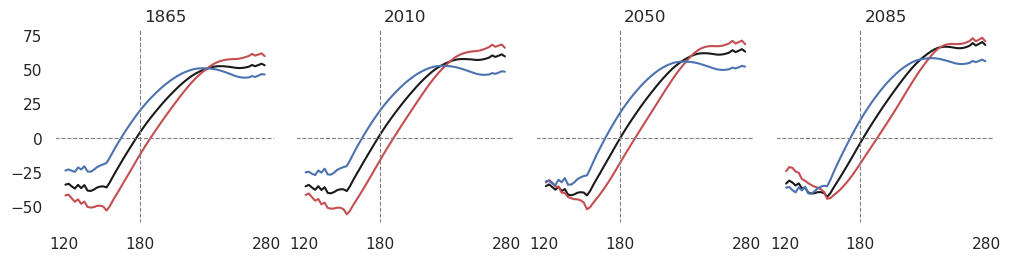

In [41]:
fig, axs = plot_zonal_structure(coefs=beta_struct, sel_fn=SEL_MONTH)

add_vticks(axs, xticks=[120, 180, 280], xlines=[180])

plt.show()

#### Scatter

##### Compute inices

In [42]:
def get_he(x):
    """average over eastern Pacific"""

    ## lats/lons for averaging
    # idx = dict(longitude=slice(190, 240))
    idx = dict(longitude=slice(210, 270))

    return reduce_y(x).sel(idx).mean("longitude")

def get_hw(x):
    """average over western Pacific"""

    ## lats/lons for averaging
    idx = dict(longitude=slice(120, 170))

    return reduce_y(x).sel(idx).mean("longitude")

    return

def get_dh(x):
    """east-west difference"""

    return get_he(x) - get_hw(x)

In [43]:
# add to dataarray
for n, fn in zip(["he","hw","dh"], [get_he, get_hw, get_dh]):
    beta_data[n] = src.utils.reconstruct_wrapper(
        anom[[y_var, f"{y_var}_comp"]],
        fn=fn,
    )[y_var]

##### Make plot

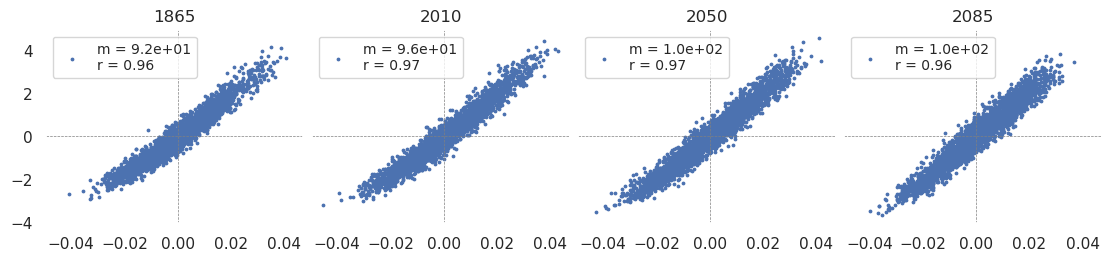

In [44]:
## specify kwargs
kwargs = dict(anom_=beta_data, xvar=x_var, yvar="dh", month=MONTH0, by_season=True)

fig, axs = make_scatter(**kwargs)
plt.show()

#### Timeseries

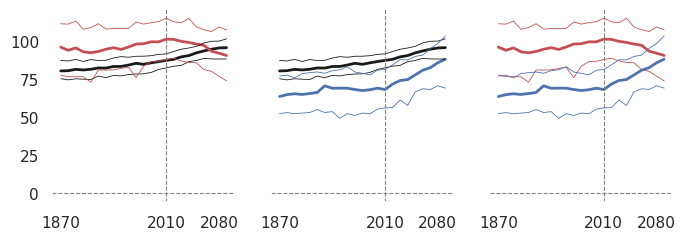

In [45]:
## compute beta index
beta = get_dh(beta_struct)

fig, axs = plot_timeseries(coefs=beta, sel_fn=SEL_MONTH)
plt.show()

### Thermal expansion

#### Compute

In [46]:
def reduce_z(x):
    """average over depth"""
    
    ## get indices
    idx = dict(longitude=slice(120, 280), z_t=slice(50, 80))

    return x.sel(idx).mean("z_t")

def postprocess_Tsub(coefs):
    """post-process regression coefficients"""

    ## reconstruct mean over equatorial region
    coefs_ = src.utils.reconstruct_wrapper(
        xr.merge([coefs, anom["T_comp"]]),
        fn=reduce_z,
    )

    ## drop extra variables
    mu = coefs_["T"].squeeze(drop=True)

    return mu

In [47]:
## get data for regression
ah_data = xr.merge([anom["T"], beta_data[["he"]]])

In [48]:
regress_kwargs = dict(x_vars=["he"], y_vars=["T"], dims=DIMS)
regress_helper = lambda x: postprocess_Tsub(regress_over_time(x, **regress_kwargs))

## do the regression
ah_all = regress_helper(ah_data)
ah_pos = regress_helper(ah_data.where(ah_data["he"] > 0))
ah_neg = regress_helper(ah_data.where(ah_data["he"] < 0))

## merge into single dataarray
ah_struct = xr.merge(
    [ah_all.rename("all"), ah_pos.rename("pos"), ah_neg.rename("neg")]
)

100%|██████████| 23/23 [00:09<00:00,  2.47it/s]


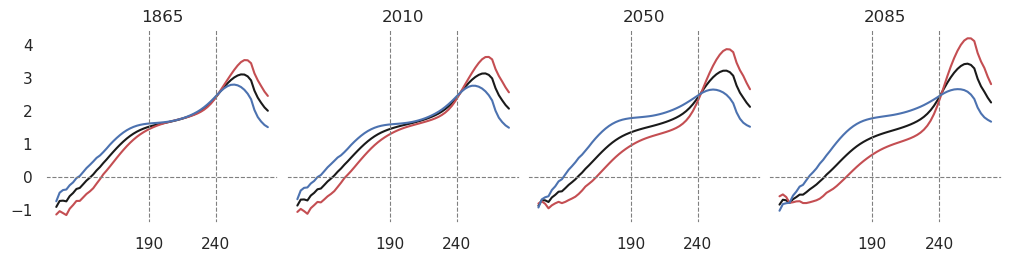

In [49]:
fig, axs = plot_zonal_structure(coefs=ah_struct, sel_fn=SEL_MONTH)

add_vticks(axs, xticks=[190, 240], xlines=[190, 240])

plt.show()

In [50]:
def reduce_x(T):
    ## specify averaging range
    idx = dict(longitude=slice(210,270))

    ## compute
    return T.sel(idx).mean("longitude")

def get_Tsub_idx(T):
    """compute Tsub over central/east Pacific"""

    ## specify averaging range
    idx = dict(longitude=slice(210,270))

    ## compute
    return reduce_x(reduce_z(T))

## add to dataarray
ah_data["Tsub"] = src.utils.reconstruct_wrapper(
    anom[["T", "T_comp"]],
    fn=get_Tsub_idx,
)["T"]

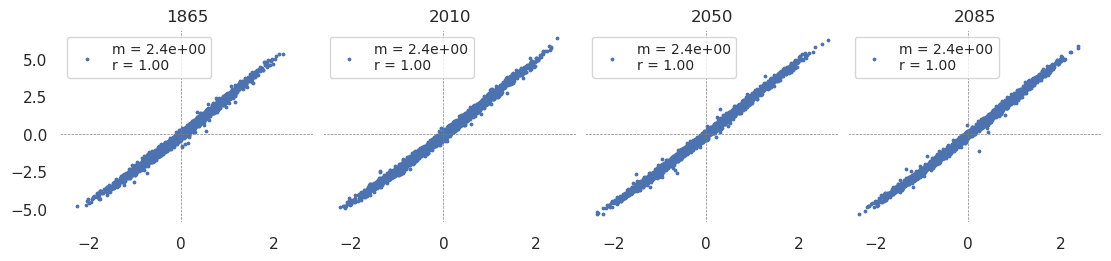

In [51]:
## specify kwargs
kwargs = dict(anom_=ah_data, xvar="he", yvar="Tsub", month=MONTH0, by_season=True)

fig, axs = make_scatter(**kwargs)
plt.show()

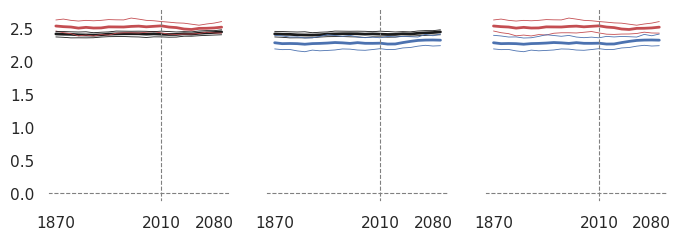

In [52]:
## get index
ah = reduce_x(ah_struct)

fig, axs = plot_timeseries(coefs=ah, sel_fn=SEL_MONTH)
plt.show()

### Plot all vars

In [53]:
## BJ, mu, beta, a_h, w, alpha

In [54]:
def plot_timeseries_v2(ax, coefs, sel_fn=SEL_MONTH, norm=True):
    """plot timeseries comparison"""

    ## normalize coefficients
    coefs_ = sel_fn(coefs)
    coefs_norm = coefs_ / coefs_.isel(year=0).mean("member")["pos"].values.item()

    ## select coefficients to plot
    if norm:
        plot_coefs = coefs_norm
    else:
        plot_coefs = coefs_

    ## loop thru pos and negative
    for i, (name, color) in enumerate(zip(["pos", "neg"], ["r", "b"])):

        ## plot median and bounds
        for q, lw in zip([0.5, 0.1, 0.9], [2, 0.6, 0.6]):
    
            ## finally, plot data
            ax.plot(
                plot_coefs.year,
                plot_coefs[name].quantile(q=q, dim="member"),
                c=color,
                lw=lw,
            )

    ## formatting
    ax.set_xticks([1870, 2010, 2080])
    ax_kwargs = dict(ls="--", c="gray", lw=0.8)
    ax.axvline(2010, **ax_kwargs)
    ax.axhline(0, **ax_kwargs)
    ax.set_yticks([])

    return fig, axs

First, plot thermocline feedback estimates

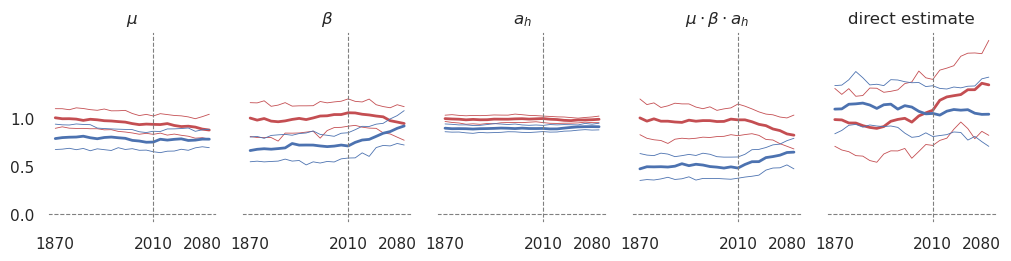

In [55]:
fig, axs = plt.subplots(1,5,figsize=(10,2.5), layout="constrained")

## mu
plot_timeseries_v2(axs[0], coefs=mu)

## beta
plot_timeseries_v2(axs[1], coefs=beta)

## THERMAL expansion
plot_timeseries_v2(axs[2], coefs=ah)

## product
plot_timeseries_v2(axs[3], coefs=mu*beta*ah)

## Direct estimate
plot_timeseries_v2(axs[4], coefs=gamma.isel(j=0))

## label
labels = [r"$\mu$",r"$\beta$", r"$a_h$", r"$\mu\cdot \beta \cdot a_h$", "direct estimate"]
for ax, label in zip(axs, labels):
    ax.set_title(label)

##formatting
src.utils.set_lims(axs)
axs[0].set_yticks([0,.5,1])

plt.show()

##### Plot growth rate stuff

Load epsilon data

In [56]:
get_coef = lambda n, v : 12 * coefs[n][f"ddt_{v}"].sel(j=v).isel(mode=0).rename(n)

R_check = xr.merge(get_coef(n, T_VAR).rename(n) for n in list(coefs))
eps = xr.merge(-get_coef(n, "h_w").rename(n) for n in list(coefs))

Check R matches

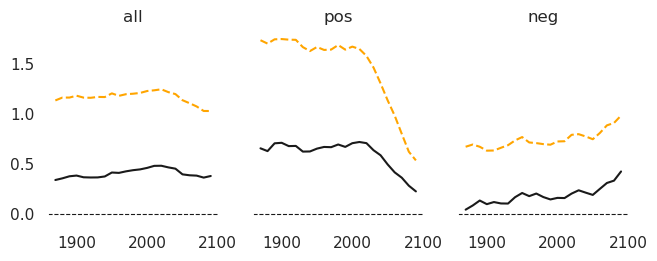

In [57]:
sel = lambda x : SEL_MONTH(x).mean("member")

## check R matches
fig,axs = plt.subplots(1,3,figsize=(7.5,2.5))
for ax, n in zip(axs, list(coefs)):
    ax.set_title(n)
    ax.plot(R.year, sel(R[n]), c="k")
    ax.plot(R.year, sel(R_check[n]), c="orange", ls="--")


for ax in axs:
    ax.axhline(0, ls="--", c="k", lw=.8)
for ax in axs[1:]:
    ax.set_yticks([])
src.utils.set_lims(axs)


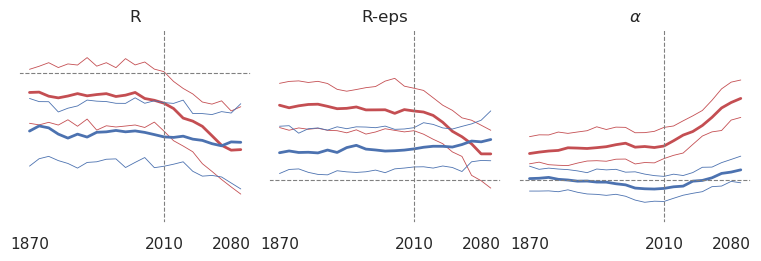

In [58]:
norm = lambda x : x/x.isel(year=0)

fig, axs = plt.subplots(1,3,figsize=(7.5,2.5), layout="constrained")

## growth rate
plot_timeseries_v2(axs[0], coefs=.5*(R_check-eps), norm=False)
## Bjerknes
plot_timeseries_v2(axs[1], coefs=R_check, norm=False)

## damping
plot_timeseries_v2(axs[2], coefs=alpha, norm=False)

## label
labels = [r"R", "R-eps", r"$\alpha$"]
for ax, label in zip(axs, labels):
    ax.set_title(label)

##formatting
axs[0].set_ylim([-1.75,.5])
for ax in axs[1:]:
    ax.set_ylim([-1,3.5])

plt.show()

### zonal velocity

#### Specify averaging region

In [ ]:
USE_T3 = True

if USE_T3:
    X_VAR = "T_3"
    TSUB_LON_RANGE = [210,270]
else:
    X_VAR = "T_34"
    TSUB_LON_RANGE = [190,240]

Makes more sense to plot vertical structure, rather than horizontal structure.

In [ ]:
def get_u(x):
    """Get diff b/n Tsub and Tsurf, but don't average over longitude yet"""

    u = x.sel(z_t=slice(None,50)).mean("z_t")

    return u

def postprocess_u(coefs):
    """post-process regression coefficients"""

    ## reconstruct mean over equatorial region
    coefs_ = src.utils.reconstruct_wrapper(
        xr.merge([coefs, anom["u_comp"]]),
        fn=get_u,
    )
    ## drop extra variables
    mu = coefs_["u"].squeeze(drop=True)

    return mu

In [ ]:
## get data for regression
betau_data = copy.deepcopy(anom[["u","T_3","T_34","h_w"]])

In [ ]:
regress_kwargs = dict(x_vars=[X_VAR,"h_w"], y_vars=["u"], dims=DIMS)
regress_helper = lambda x: postprocess_u(regress_over_time(x, **regress_kwargs))

## do the regression
betau_all = regress_helper(betau_data)
betau_pos = regress_helper(betau_data.where(betau_data[X_VAR] > 0))
betau_neg = regress_helper(betau_data.where(betau_data[X_VAR] < 0))

## merge into single dataarray
betau = xr.merge(
    [betau_all.rename("all"), betau_pos.rename("pos"), betau_neg.rename("neg")]
)

#### Plot structure

In [ ]:
for v in [X_VAR,"h_w"]:
    print(v)
    fig, axs = plot_zonal_structure(coefs=betau.sel(j=v), sel_fn=SEL_MONTH)
    add_vticks(axs, xticks=[190,240,280], xlines=[190,240])
    axs[0].set_ylabel(r"$u$")

    plt.show()

#### Scatter

In [ ]:
def get_u_idx(x):
    """compute u over central/east Pacific"""

    if "z_t" in x.dims:
        x_ = copy.deepcopy(x)
    else:
        x_ = x.expand_dims("z_t")

    ## specify averaging region
    idx = dict(longitude=slice(190,240), z_t=slice(None,50))
    
    ## compute
    return x_.sel(idx).mean(["longitude","z_t"])


## add to dataarray
betau_data["u_34"] = src.utils.reconstruct_wrapper(
    anom[["u", "u_comp"]],
    fn=get_u_idx,
)["u"]

In [ ]:
## specify kwargs
kwargs = dict(anom_=betau_data, yvar="u_34", month=MONTH0)

for v in [X_VAR, "h_w"]:
    print(v)
    fig, axs = make_scatter(xvar=v, **kwargs)
    plt.show()

#### Timeseries

In [ ]:
## get index
sel = lambda x: SEL_MONTH(get_u_idx(x)).isel(j=0)

fig, axs = plot_timeseries(coefs=betau, sel_fn=sel)
plt.show()